# ERC and Reg S-K Human Capital Disclosure

## Project Overview

This notebook estimates the Earnings Response Coefficient (ERC) regression to examine whether the SEC Reg S-K HCD mandate (effective November 2020) increased the informativeness of earnings for investors, and whether the effect is stronger for firms with higher pre-period HCD intensity.

### Model

$$AR_{i,t} = \alpha + \beta_1 UE_{i,t} + \beta_2 Post_t \times HCD_i \times UE_{i,t} + \mu_i + \lambda_t + \varepsilon_{i,t}$$

- $AR_{i,t}$: buy-and-hold abnormal return (market-adjusted or raw)
- $UE_{i,t}$: unexpected earnings (scaled by lagged market value)
- $HCD_i$: pre-period HCD intensity (`exposure_pre_std`, FY2015–2019 average, standardized)
- $\beta_1$: baseline ERC
- $\beta_2$: key coefficient — does high-HCD exposure amplify ERC post-mandate? Predicted $\hat{\beta}_2 > 0$
- Firm FE + Year FE; SE clustered by firm

### Data Sources
- Compustat `funda`: earnings variables
- Compustat `fundq`: Q1 market value scaler
- CRSP `msf_v2`: monthly stock returns
- CRSP `msi`: market index returns
- CCM link table: gvkey → permno
- `hcd_exposure.csv`: pre-period HCD intensity (read-only)

### Construction follows Yeyang_Week8_v3.ipynb exactly for all return and earnings variables.


---
## 0. Configuration
> **All parameters that may need to be changed are defined here. Do not hard-code values elsewhere.**

In [1]:
# ============================================================
# CONFIGURATION — Change parameters here only
# ============================================================

# --- File Paths (Compustat / CRSP) ---
DB              = '<PATH_TO_WRDS_DATA>'   # update to your local WRDS data directory
FUNDA_PATH      = f'{DB}/funda.sas7bdat'
FUNDQ_PATH      = f'{DB}/fundq.sas7bdat'
MSF_PATH        = f'{DB}/msf_v2.sas7bdat'
MSI_PATH        = f'{DB}/msi.sas7bdat'
CCM_PATH        = f'{DB}/ccmxpf_lnkhist.sas7bdat'

# --- File Paths (IBES) ---
IBES_DB         = '<PATH_TO_IBES_DATA>'   # update to your local IBES data directory
ACT_EPS_PATH    = f'{IBES_DB}/act_epsus.sas7bdat'
STATSUM_PATH    = f'{IBES_DB}/statsum_epsus.sas7bdat'
SECURITY_PATH   = f'{IBES_DB}/security.sas7bdat'

# --- HCD ---
PATH_HCD        = './hcd_exposure.csv'
OUT_DIR         = './output'

# --- Reg S-K Event Parameters ---
POST_YEAR_OPTIONS = [2020, 2021]
POST_YEAR         = 2020          # default for single-run

# --- Sample Window ---
WINDOW_OPTIONS = [3, 5]
WINDOW         = 3

# --- Return Windows (following Week8 v3) ---
WINDOWS = {
    'm9p3': (-8,  3),
    'm12p': (-11, 0),
}

# --- Unexpected Earnings variables (5 measures) ---
# IB_L1MV:    level of IB scaled by lagged MV
# c1IB_L1MV:  change in IB scaled by lagged MV  (random-walk UE)
# c1IB_L1P:   change in EPS scaled by lagged price
# c1IB_L1TA:  change in IB scaled by lagged total assets
# UE_IBES:    (Actual EPS - Median Forecast) / Lagged Price (analyst-based UE)
UE_VARS = ['IB_L1MV', 'c1IB_L1MV', 'c1IB_L1P', 'c1IB_L1TA', 'UE_IBES']

# --- Return variables ---
RET_VARS = ['BHRetm9p3', 'BHRetm12p', 'BHRetMktm9p3', 'BHRetMktm12p']

# --- Outlier Treatment ---
OUTLIER_P = 0.01

# --- CCM link filters ---
LINK_TYPES = ['LU', 'LC']
LINK_PRIM  = ['P', 'C']

# --- Compustat standard filters ---
COMP_FILTER = dict(indfmt='INDL', datafmt='STD', popsrc='D', consol='C')

# --- Industry exclusions (SIC) ---
EXCL_SIC_RANGES = [(6000, 6999),   # Financials
                   (4900, 4949)]   # Utilities

# --- IBES filters ---
IBES_PDICITY    = 'ANN'    # annual periodicity
IBES_FPI        = '1'      # current fiscal year forecast
IBES_MEASURE    = 'EPS'
IBES_USFIRM     = 1

# --- Regression ---
CLUSTER_VAR = 'gvkey'

# ============================================================
import os
os.makedirs(OUT_DIR, exist_ok=True)
n_combos = len(POST_YEAR_OPTIONS) * len(WINDOW_OPTIONS) * len(UE_VARS) * len(RET_VARS)
print('Configuration loaded.')
print(f'  Post years:   {POST_YEAR_OPTIONS}')
print(f'  Windows:      {["±"+str(w) for w in WINDOW_OPTIONS]}')
print(f'  UE vars:      {UE_VARS}')
print(f'  Return vars:  {RET_VARS}')
print(f'  Excl SIC:     {EXCL_SIC_RANGES}')
print(f'  → {n_combos} main regression combinations')


Configuration loaded.
  Post years:   [2020, 2021]
  Windows:      ['±3', '±5']
  UE vars:      ['IB_L1MV', 'c1IB_L1MV', 'c1IB_L1P', 'c1IB_L1TA', 'UE_IBES']
  Return vars:  ['BHRetm9p3', 'BHRetm12p', 'BHRetMktm9p3', 'BHRetMktm12p']
  Excl SIC:     [(6000, 6999), (4900, 4949)]
  → 80 main regression combinations


---
## 1. Imports

In [2]:
import warnings
import numpy as np
import pandas as pd
import pyreadstat
from linearmodels.panel import PanelOLS

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)
print('Libraries loaded.')


Libraries loaded.


---
## 2. Compustat: Earnings & Price Variables

Following Week8 v3 exactly: load `funda`, construct `L1MV`, `IB_L1MV`, `c1IB_L1MV`.

In [3]:
# ── 2.1 Load funda ───────────────────────────────────────────────────────────
cols = ['gvkey','datadate','fyear','fyr','indfmt','datafmt','popsrc','consol',
        'ib','at','csho','prcc_f','sich']
raw, _ = pyreadstat.read_sas7bdat(FUNDA_PATH, usecols=cols)
raw.columns = raw.columns.str.lower()
raw['datadate'] = pd.to_datetime(raw['datadate'].astype(float), unit='D', origin='1960-01-01')
raw['gvkey']    = raw['gvkey'].astype(str).str.zfill(6)
print(f'Raw funda: {len(raw):,} rows')


Raw funda: 930,107 rows


In [4]:
# ── 2.2 Standard Compustat filters + Industry exclusions ─────────────────────
df = raw.copy()

# Standard Compustat filters
for col, val in COMP_FILTER.items():
    df = df[df[col] == val]

# Drop duplicates
df = (df.sort_values(['gvkey','fyear','datadate'])
        .drop_duplicates(['gvkey','fyear'], keep='last'))
print(f'After standard filters:           {len(df):>8,} firm-years '
      f'({df["gvkey"].nunique():>6,} firms)')

# Exclude financials and utilities
sic_col = 'sich' if 'sich' in df.columns else 'sic'
sic_num = pd.to_numeric(df[sic_col], errors='coerce')
excl_mask = pd.Series(False, index=df.index)
for lo, hi in EXCL_SIC_RANGES:
    excl_mask |= sic_num.between(lo, hi)
df = df[~excl_mask].copy()
print(f'After SIC exclusions (fin+util):  {len(df):>8,} firm-years '
      f'({df["gvkey"].nunique():>6,} firms)')


After standard filters:            593,815 firm-years (46,661 firms)
After SIC exclusions (fin+util):   531,998 firm-years (45,048 firms)


In [5]:
# ── 2.3 Scalers and earnings variables (Week8 v3 + extended UE measures) ────
df = df.sort_values(['gvkey','fyear'])
g  = df.groupby('gvkey')

df['mv']        = df['csho'] * df['prcc_f']
df['fyear_lag'] = g['fyear'].shift(1)
df['L1MV']      = g['mv'].shift(1)
df['L1TA']      = g['at'].shift(1)
df['L1P']       = g['prcc_f'].shift(1)        # lagged price per share
df['IB_lag']    = g['ib'].shift(1)
df['EPS_lag']   = (g['ib'].shift(1) / g['csho'].shift(1))   # lagged EPS for L1P scaling

# Invalidate lags where fiscal years are not consecutive
gap = (df['fyear'] - df['fyear_lag']) != 1
df.loc[gap, ['L1MV','L1TA','L1P','IB_lag','EPS_lag']] = np.nan
df.loc[df['L1MV'] <= 0, 'L1MV'] = np.nan
df.loc[df['L1TA'] <= 0, 'L1TA'] = np.nan
df.loc[df['L1P']  <= 0, 'L1P']  = np.nan

# UE measure 1: level / lagged MV
df['IB_L1MV']    = df['ib']                  / df['L1MV']

# UE measure 2: ΔE / lagged MV
df['c1IB_L1MV']  = (df['ib'] - df['IB_lag']) / df['L1MV']

# UE measure 3: ΔEPS / lagged price (per share basis)
df['EPS']        = df['ib'] / df['csho']
df['c1IB_L1P']   = (df['EPS'] - df['EPS_lag']) / df['L1P']

# UE measure 4: ΔE / lagged TA
df['c1IB_L1TA']  = (df['ib'] - df['IB_lag']) / df['L1TA']

for v in ['L1MV','L1TA','L1P','IB_L1MV','c1IB_L1MV','c1IB_L1P','c1IB_L1TA']:
    print(f'{v:<14} non-null: {df[v].notna().sum():>8,}')


L1MV           non-null:  376,216
L1TA           non-null:  396,473
L1P            non-null:  381,224
IB_L1MV        non-null:  313,178
c1IB_L1MV      non-null:  311,821
c1IB_L1P       non-null:  311,493
c1IB_L1TA      non-null:  392,550


In [6]:
# ── 2.2b Sample Selection Waterfall (pre-merge) ──────────────────────────────
# Track how each filter step shrinks the sample.

waterfall_pre = []

# Step 0: raw Compustat
waterfall_pre.append(('0. Raw Compustat firm-years',
                      len(raw), raw['gvkey'].nunique()))

# Step 1: after standard filters (INDL/STD/D/C, dedup)
df_t = raw.copy()
for col, val in COMP_FILTER.items():
    df_t = df_t[df_t[col] == val]
df_t = (df_t.sort_values(['gvkey','fyear','datadate'])
              .drop_duplicates(['gvkey','fyear'], keep='last'))
waterfall_pre.append(('1. After standard filters (INDL/STD/D/C)',
                      len(df_t), df_t['gvkey'].nunique()))

# Step 2: after SIC exclusions
sic_col = 'sich' if 'sich' in df_t.columns else 'sic'
sic_num = pd.to_numeric(df_t[sic_col], errors='coerce')
excl_mask = pd.Series(False, index=df_t.index)
for lo, hi in EXCL_SIC_RANGES:
    excl_mask |= sic_num.between(lo, hi)
df_t = df_t[~excl_mask].copy()
waterfall_pre.append(('2. After excl. financials & utilities',
                      len(df_t), df_t['gvkey'].nunique()))

# Step 3: after non-missing IB, AT, MV>0
df_t['mv_t'] = df_t['csho'] * df_t['prcc_f']
df_t = df_t.dropna(subset=['ib','at','mv_t'])
df_t = df_t[(df_t['at']>0) & (df_t['mv_t']>0)]
waterfall_pre.append(('3. After non-missing IB, AT, MV>0',
                      len(df_t), df_t['gvkey'].nunique()))

# Step 4: current df after lag construction (IB_L1MV non-null)
waterfall_pre.append(('4. After lag completeness (consec years)',
                      df['IB_L1MV'].notna().sum(),
                      df.loc[df['IB_L1MV'].notna(),'gvkey'].nunique()))

# Print
print(f"\nPre-merge waterfall:")
print(f"{'Step':<55}{'N obs':>10}{'N firms':>10}")
print('-' * 78)
for step, n, nf in waterfall_pre:
    print(f'{step:<55}{n:>10,}{nf:>10,}')

# Save for later use
import pandas as pd
waterfall_pre_df = pd.DataFrame(waterfall_pre, columns=['Step','N_obs','N_firms'])



Pre-merge waterfall:
Step                                                        N obs   N firms
------------------------------------------------------------------------------
0. Raw Compustat firm-years                               930,107    47,050
1. After standard filters (INDL/STD/D/C)                  593,815    46,661
2. After excl. financials & utilities                     531,998    45,048
3. After non-missing IB, AT, MV>0                         341,781    30,851
4. After lag completeness (consec years)                  313,178    28,863


### 2.4 L1MVQ1: end-of-Q1 market value from fundq

Following Week8 v3: Q1 = fiscal quarter 1 of fiscal year t. Market value = cshoq × prccq.

In [7]:
# ── 2.4 L1MVQ1 from fundq (following Week8 v3) ──────────────────────────────
q_cols = ['gvkey','fyearq','fqtr','cshoq','prccq',
          'indfmt','datafmt','popsrc','consol']
fq, _ = pyreadstat.read_sas7bdat(FUNDQ_PATH, usecols=q_cols)
fq.columns = fq.columns.str.lower()
fq['gvkey'] = fq['gvkey'].astype(str).str.zfill(6)

fq = fq[(fq['indfmt']  == 'INDL') & (fq['datafmt'] == 'STD') &
         (fq['popsrc']  == 'D')    & (fq['consol']  == 'C') &
         (fq['fqtr']    == 1)].copy()

fq['L1MVQ1'] = fq['cshoq'] * fq['prccq']
fq.loc[fq['L1MVQ1'] <= 0, 'L1MVQ1'] = np.nan
fq = fq[['gvkey','fyearq','L1MVQ1']].rename(columns={'fyearq':'fyear'})
fq = fq.dropna(subset=['L1MVQ1'])

df = df.merge(fq[['gvkey','fyear','L1MVQ1']], on=['gvkey','fyear'], how='left')
df['IB_L1MVQ1']   = df['ib']                  / df['L1MVQ1']
df['c1IB_L1MVQ1'] = (df['ib'] - df['IB_lag']) / df['L1MVQ1']
print(f'L1MVQ1 non-null: {df["L1MVQ1"].notna().sum():,}')


L1MVQ1 non-null: 299,498


---
## 3. CRSP: Return Variables

Build `BHRetm9p3`, `BHRetm12p` (raw) and market-adjusted versions. Following Week8 v3 exactly.

In [8]:
# ── 3.1 CCM: gvkey → permno (following Week8 v3) ────────────────────────────
ccm, _ = pyreadstat.read_sas7bdat(
    CCM_PATH, usecols=['GVKEY','LPERMNO','LINKTYPE','LINKPRIM','LINKDT','LINKENDDT'])
ccm.columns = ccm.columns.str.lower()
ccm['gvkey']     = ccm['gvkey'].astype(str).str.zfill(6)
ccm['permno']    = ccm['lpermno'].astype('Int64')
ccm['linkdt']    = pd.to_datetime(ccm['linkdt'].astype(float), unit='D', origin='1960-01-01')
ccm['linkenddt'] = pd.to_datetime(ccm['linkenddt'].astype(float), unit='D', origin='1960-01-01').fillna(pd.Timestamp('2099-12-31'))
ccm = ccm[ccm['linktype'].isin(LINK_TYPES) & ccm['linkprim'].isin(LINK_PRIM)]

link = (df[['gvkey','fyear','datadate']]
        .merge(ccm[['gvkey','permno','linkdt','linkenddt']], on='gvkey', how='left'))
link = link[(link['datadate'] >= link['linkdt']) & (link['datadate'] <= link['linkenddt'])]
link = (link.sort_values(['gvkey','fyear','permno'])
            .drop_duplicates(['gvkey','fyear'], keep='first')
            [['gvkey','fyear','permno']])
print(f'CCM link: {len(link):,} gvkey-fyear pairs with permno')


CCM link: 292,996 gvkey-fyear pairs with permno


In [9]:
# ── 3.2 msi: monthly market return (following Week8 v3) ──────────────────────
msi, _ = pyreadstat.read_sas7bdat(MSI_PATH)
msi.columns = msi.columns.str.lower()
msi['date']   = pd.to_datetime(msi['date'])
msi['yyyymm'] = msi['date'].dt.year * 100 + msi['date'].dt.month
msi['vwretd'] = pd.to_numeric(msi['vwretd'], errors='coerce')
mkt = msi[['yyyymm','vwretd']].copy()
print(f'msi: {len(mkt):,} months')


msi: 1,189 months


In [10]:
# ── 3.3 msf_v2: individual stock returns (following Week8 v3) ───────────────
msf, _ = pyreadstat.read_sas7bdat(
    MSF_PATH,
    usecols=['PERMNO','YYYYMM','MthRet','ShareType','SecurityType','USIncFlg','PrimaryExch'])
msf.columns = msf.columns.str.lower()
msf['permno'] = msf['permno'].astype('Int64')
msf['yyyymm'] = msf['yyyymm'].astype(int)
msf['ret']    = pd.to_numeric(msf['mthret'], errors='coerce')

msf = msf[(msf['sharetype']    == 'NS')   &
          (msf['securitytype'] == 'EQTY') &
          (msf['usincflg']     == 'Y')    &
          (msf['primaryexch'].isin(['N','A','Q']))].copy()

msf = msf.merge(mkt, on='yyyymm', how='left')
print(f'msf_v2 filtered: {len(msf):,} obs')


msf_v2 filtered: 3,944,611 obs


### 3.4 BH return windows

`BHRetm9p3` = buy-and-hold over (-8, +3) relative to FYE month.
`BHRetm12p` = buy-and-hold over (-11, 0) relative to FYE month.
Market-adjusted versions subtract VW market return each month.

In [11]:
# ── 3.4 Compute BH return windows (following Week8 v3) ──────────────────────
def add_offset(yyyymm, offset):
    y, m = divmod(yyyymm, 100)
    t = y * 12 + (m - 1) + offset
    return (t // 12) * 100 + (t % 12) + 1

fw = df[['gvkey','fyear','datadate']].merge(link, on=['gvkey','fyear'])
fw['ym'] = fw['datadate'].dt.year * 100 + fw['datadate'].dt.month

def agg_bh(g, suffix):
    r = g['ret'].dropna()
    a = g['ar'].dropna()
    if len(r) == 0:
        return pd.Series({f'BHRet_{suffix}': np.nan, f'BHRetMkt_{suffix}': np.nan})
    return pd.Series({
        f'BHRet_{suffix}':    (1 + r).prod() - 1,
        f'BHRetMkt_{suffix}': (1 + a).prod() - 1,
    })

ret_ann = fw[['gvkey','fyear']].drop_duplicates()
for suffix, (win_start, win_end) in WINDOWS.items():
    fw['r_beg'] = fw['ym'].apply(lambda x: add_offset(x, win_start))
    fw['r_end'] = fw['ym'].apply(lambda x: add_offset(x, win_end))
    m = (fw[['gvkey','fyear','permno','r_beg','r_end']]
         .merge(msf[['permno','yyyymm','ret','vwretd']], on='permno', how='left'))
    m = m[(m['yyyymm'] >= m['r_beg']) & (m['yyyymm'] <= m['r_end'])]
    m['ar'] = m['ret'] - m['vwretd']
    r_w = m.groupby(['gvkey','fyear']).apply(agg_bh, suffix=suffix).reset_index()
    ret_ann = ret_ann.merge(r_w, on=['gvkey','fyear'], how='left')

ret_ann = ret_ann.rename(columns={
    'BHRet_m9p3':    'BHRetm9p3',
    'BHRet_m12p':    'BHRetm12p',
    'BHRetMkt_m9p3': 'BHRetMktm9p3',
    'BHRetMkt_m12p': 'BHRetMktm12p',
})
print(f'Annual BH returns: {len(ret_ann):,} obs')
for c in [col for col in ret_ann.columns if col.startswith('BH')]:
    print(f'  {c}: {ret_ann[c].notna().sum():,}')


Annual BH returns: 292,996 obs
  BHRetm9p3: 240,721
  BHRetMktm9p3: 240,721
  BHRetm12p: 240,654
  BHRetMktm12p: 240,654


---
## 4. Merge → RetEarn

In [12]:
# ── 4. Merge all variables into RetEarn ─────────────────────────────────────
keep = ['gvkey','fyear','datadate','fyr','ib','at','csho','prcc_f',
        'L1MV','L1MVQ1','L1P',
        'IB_L1MV','c1IB_L1MV','c1IB_L1P','c1IB_L1TA',
        'IB_L1MVQ1','c1IB_L1MVQ1']

RetEarn = (df[[c for c in keep if c in df.columns]]
           .merge(ret_ann, on=['gvkey','fyear'], how='left'))

print(f'RetEarn: {RetEarn.shape}')
for v in ['BHRetm9p3','BHRetm12p','BHRetMktm9p3','BHRetMktm12p',
          'IB_L1MV','c1IB_L1MV','c1IB_L1P','c1IB_L1TA',
          'IB_L1MVQ1','c1IB_L1MVQ1']:
    if v in RetEarn.columns:
        print(f'  {v}: {RetEarn[v].notna().sum():,}')


RetEarn: (532356, 21)
  BHRetm9p3: 240,893
  BHRetm12p: 240,826
  BHRetMktm9p3: 240,893
  BHRetMktm12p: 240,826
  IB_L1MV: 313,510
  c1IB_L1MV: 312,152
  c1IB_L1P: 311,823
  c1IB_L1TA: 392,879
  IB_L1MVQ1: 273,611
  c1IB_L1MVQ1: 268,161


### 4b. IBES Analyst Forecast — Construct UE_IBES

Build analyst-based unexpected earnings: `UE_IBES = (Actual EPS − Median Forecast) / Lagged Price`.

Forecast horizon: last consensus before each firm-period's earnings announcement date.


In [13]:
# ── 4b.1 Load Compustat security table for gvkey ↔ IBES ticker link ─────────
print('Loading Compustat security table for gvkey ↔ ibtic link...')
sec_raw, _ = pyreadstat.read_sas7bdat(SECURITY_PATH)
sec_raw.columns = sec_raw.columns.str.lower()
print(f'  security raw: {len(sec_raw):,} rows, columns: {sec_raw.columns.tolist()[:15]}...')

# Find ibtic column (could be 'ibtic' or similar)
ibtic_col = None
for c in ['ibtic','IBTIC','ibesticker']:
    if c in sec_raw.columns:
        ibtic_col = c
        break
assert ibtic_col is not None, 'No IBES ticker column in security table'
print(f'  IBES ticker column: {ibtic_col}')

# gvkey ↔ ibtic mapping (drop missing)
sec_link = (sec_raw[['gvkey', ibtic_col]]
            .dropna()
            .rename(columns={ibtic_col: 'ibtic'})
            .drop_duplicates())
print(f'  unique gvkey-ibtic pairs: {len(sec_link):,}')
print(f'  unique gvkey:             {sec_link["gvkey"].nunique():,}')
print(f'  unique ibtic:             {sec_link["ibtic"].nunique():,}')


Loading Compustat security table for gvkey ↔ ibtic link...
  security raw: 76,295 rows, columns: ['tic', 'gvkey', 'iid', 'cusip', 'dlrsni', 'dsci', 'epf', 'exchg', 'excntry', 'ibtic', 'isin', 'secstat', 'sedol', 'tpci', 'dldtei']...
  IBES ticker column: ibtic
  unique gvkey-ibtic pairs: 63,459
  unique gvkey:             57,362
  unique ibtic:             27,201


In [14]:
# ── 4b.2 Load IBES Actual EPS ────────────────────────────────────────────────
print('Loading IBES actual EPS...')
act_raw, _ = pyreadstat.read_sas7bdat(ACT_EPS_PATH)
act_raw.columns = act_raw.columns.str.lower()
print(f'  act_epsus raw: {len(act_raw):,} rows')
print(f'  columns: {act_raw.columns.tolist()}')

# Filter: annual periodicity, EPS measure, US firms, valid dates and value
act = act_raw.copy()
filters_applied = []

if 'pdicity' in act.columns:
    act = act[act['pdicity'].astype(str).str.upper() == IBES_PDICITY]
    filters_applied.append(f'pdicity={IBES_PDICITY}')
if 'measure' in act.columns:
    act = act[act['measure'].astype(str).str.upper() == IBES_MEASURE]
    filters_applied.append(f'measure={IBES_MEASURE}')
if 'usfirm' in act.columns:
    act = act[act['usfirm'] == IBES_USFIRM]
    filters_applied.append(f'usfirm={IBES_USFIRM}')

# Drop missing announcement date or value
act = act.dropna(subset=['anndats','value'])
filters_applied.append('non-null anndats, value')

# Optional: announcement date <= actual date
if 'actdats' in act.columns:
    act = act[act['anndats'] <= act['actdats']]
    filters_applied.append('anndats<=actdats')

print(f'  After filters ({", ".join(filters_applied)}): {len(act):,} rows')

# Standardize columns: ticker, pends (period end), anndats, value (actual EPS)
act = act[['ticker','pends','anndats','value']].rename(columns={'value':'actual_eps'})

# Sanity check: one obs per ticker × pends
act = act.sort_values(['ticker','pends','anndats']).drop_duplicates(['ticker','pends'], keep='last')
print(f'  Unique ticker×pends after dedup: {len(act):,}')
print(act.head())


Loading IBES actual EPS...
  act_epsus raw: 1,313,147 rows
  columns: ['ticker', 'cusip', 'oftic', 'cname', 'pends', 'measure', 'pdicity', 'anndats', 'anntims', 'actdats', 'acttims', 'value', 'curr_act', 'usfirm']
  After filters (pdicity=ANN, measure=EPS, usfirm=1, non-null anndats, value, anndats<=actdats): 219,190 rows
  Unique ticker×pends after dedup: 218,889
   ticker       pends     anndats  actual_eps
14   0000  2014-12-31  2015-01-30      1.2100
19   0000  2015-12-31  2016-01-26      1.0200
28   0001  2013-12-31  2014-02-27     -0.2800
33   0001  2014-12-31  2015-02-18      0.8600
38   0001  2015-12-31  2016-02-18      0.7800


In [15]:
# ── 4b.3 Load IBES Summary statistics, pick last consensus before announcement ─
print('Loading IBES summary statistics...')
sum_raw, _ = pyreadstat.read_sas7bdat(STATSUM_PATH)
sum_raw.columns = sum_raw.columns.str.lower()
print(f'  statsum_epsus raw: {len(sum_raw):,} rows')
print(f'  columns: {sum_raw.columns.tolist()}')

# Filter: FY1 (current fiscal year), EPS, US firms, non-missing median
ssum = sum_raw.copy()
filters_applied = []

if 'fpi' in ssum.columns:
    ssum = ssum[ssum['fpi'].astype(str) == IBES_FPI]
    filters_applied.append(f'fpi={IBES_FPI}')
if 'measure' in ssum.columns:
    ssum = ssum[ssum['measure'].astype(str).str.upper() == IBES_MEASURE]
    filters_applied.append(f'measure={IBES_MEASURE}')
if 'usfirm' in ssum.columns:
    ssum = ssum[ssum['usfirm'] == IBES_USFIRM]
    filters_applied.append(f'usfirm={IBES_USFIRM}')

# medest = median forecast
ssum = ssum.dropna(subset=['medest','statpers','fpedats'])
filters_applied.append('non-null medest, statpers, fpedats')

print(f'  After filters ({", ".join(filters_applied)}): {len(ssum):,} rows')

# Keep what we need: ticker, fpedats (FY end), statpers (forecast snapshot date), medest, numest
keep_cols = ['ticker','fpedats','statpers','medest']
if 'numest' in ssum.columns:
    keep_cols.append('numest')
ssum = ssum[keep_cols].copy()
print(ssum.head())
print(f'  Unique ticker×fpedats: {ssum.groupby(["ticker","fpedats"]).ngroups:,}')


Loading IBES summary statistics...
  statsum_epsus raw: 14,925,151 rows
  columns: ['ticker', 'cusip', 'oftic', 'cname', 'statpers', 'measure', 'fiscalp', 'fpi', 'estflag', 'curcode', 'numest', 'numup', 'numdown', 'medest', 'meanest', 'stdev', 'highest', 'lowest', 'usfirm', 'fpedats', 'actual', 'actdats_act', 'acttims_act', 'anndats_act', 'anntims_act', 'curr_act']
  After filters (fpi=1, measure=EPS, usfirm=1, non-null medest, statpers, fpedats): 2,427,059 rows
   ticker     fpedats    statpers  medest  numest
12   0000  2014-12-31  2014-04-17  0.5100  4.0000
13   0000  2014-12-31  2014-05-15  0.5800  4.0000
14   0000  2014-12-31  2014-06-19  0.5800  4.0000
15   0000  2014-12-31  2014-07-17  0.5800  3.0000
16   0000  2014-12-31  2014-08-14  1.1700  5.0000
  Unique ticker×fpedats: 228,727


In [16]:
# ── 4b.4 Merge: pick last forecast before announcement; merge to gvkey ──────
print('Merging IBES actual + summary...')

# Step 1: merge actual to summary on (ticker, fpedats=pends)
merged = ssum.merge(
    act, left_on=['ticker','fpedats'], right_on=['ticker','pends'], how='inner'
)
print(f'  After ticker×pends match: {len(merged):,} rows')

# Step 2: keep only forecasts dated BEFORE announcement
merged = merged[merged['statpers'] < merged['anndats']]
print(f'  After statpers < anndats: {len(merged):,} rows')

# Step 3: pick the LAST consensus snapshot before announcement
merged = (merged.sort_values(['ticker','fpedats','statpers'])
                .drop_duplicates(['ticker','fpedats'], keep='last'))
print(f'  After picking last snapshot: {len(merged):,} unique ticker×fpedats')

# Step 4: link to gvkey via security table
merged = merged.merge(sec_link, left_on='ticker', right_on='ibtic', how='inner')
print(f'  After gvkey link: {len(merged):,} rows')
print(f'  Unique gvkey: {merged["gvkey"].nunique():,}')

# Step 5: derive fyear from fpedats (calendar year of fiscal period end)
merged['ibes_fyear'] = pd.to_datetime(merged['fpedats']).dt.year
# Note: if fyr month is < 6, fiscal year may be calendar year - 1; handled by merging on fyear directly later

# Save with surprise computed in next cell after price merge
ibes_panel = merged[['gvkey','ibes_fyear','fpedats','anndats','actual_eps','medest']].copy()
ibes_panel = ibes_panel.rename(columns={'ibes_fyear':'fyear'})

# Dedup: one obs per gvkey × fyear (some firms have multiple fiscal periods per calendar year)
ibes_panel = (ibes_panel.sort_values(['gvkey','fyear','fpedats'])
                       .drop_duplicates(['gvkey','fyear'], keep='last'))
print(f'  Final ibes_panel: {len(ibes_panel):,} rows ({ibes_panel["gvkey"].nunique():,} firms)')
print(ibes_panel.head())


Merging IBES actual + summary...
  After ticker×pends match: 2,024,246 rows
  After statpers < anndats: 1,999,135 rows
  After picking last snapshot: 182,617 unique ticker×fpedats
  After gvkey link: 169,476 rows
  Unique gvkey: 16,741
  Final ibes_panel: 168,853 rows (16,741 firms)
        gvkey  fyear     fpedats     anndats  actual_eps  medest
13131  001003   1984  1984-12-31  1985-04-04      1.3200  0.2000
9153   001004   1983  1983-05-31  1983-07-28      0.2102  0.2200
9154   001004   1986  1986-05-31  1986-07-08      0.5642  0.5500
9155   001004   1987  1987-05-31  1987-07-14      0.6662  0.6700
9156   001004   1988  1988-05-31  1988-07-21      0.8927  0.8700


In [17]:
# ── 4b.5 Compute UE_IBES and merge into RetEarn ─────────────────────────────
# UE_IBES = (Actual EPS - Median Forecast) / Lagged Price

# Pull L1P from RetEarn (already constructed)
ibes_with_price = ibes_panel.merge(
    RetEarn[['gvkey','fyear','L1P']], on=['gvkey','fyear'], how='left'
)
print(f'After merge with L1P: {len(ibes_with_price):,} rows')
print(f'  L1P non-null: {ibes_with_price["L1P"].notna().sum():,}')

# --- Filter extreme cases at construction (before division) ---
# (1) Drop tiny L1P (< $1) to avoid division by near-zero blowup
n_before = len(ibes_with_price)
ibes_with_price = ibes_with_price[ibes_with_price['L1P'].abs() >= 1.0]
print(f'  After |L1P| >= $1 filter: {len(ibes_with_price):,} rows '
      f'(dropped {n_before - len(ibes_with_price):,})')

# (2) Compute UE_IBES
ibes_with_price['UE_IBES'] = (
    (ibes_with_price['actual_eps'] - ibes_with_price['medest'])
    / ibes_with_price['L1P']
)

# (3) Drop |UE_IBES| > 1 (these are non-economic — surprise > 100% of price)
n_before = len(ibes_with_price)
ibes_with_price = ibes_with_price[ibes_with_price['UE_IBES'].abs() <= 1.0]
print(f'  After |UE_IBES| <= 1 filter: {len(ibes_with_price):,} rows '
      f'(dropped {n_before - len(ibes_with_price):,})')

print(f'\n  UE_IBES non-null after filters: {ibes_with_price["UE_IBES"].notna().sum():,}')
print(f'  UE_IBES describe (after filters):')
print(ibes_with_price['UE_IBES'].describe())

# Merge UE_IBES into RetEarn (one column added)
RetEarn = RetEarn.merge(
    ibes_with_price[['gvkey','fyear','UE_IBES','actual_eps','medest','anndats']],
    on=['gvkey','fyear'], how='left'
)
print(f'\nRetEarn after IBES merge: {RetEarn.shape}')
print(f'  UE_IBES non-null: {RetEarn["UE_IBES"].notna().sum():,}')


After merge with L1P: 168,966 rows
  L1P non-null: 123,856
  After |L1P| >= $1 filter: 121,021 rows (dropped 47,945)
  After |UE_IBES| <= 1 filter: 117,859 rows (dropped 3,162)

  UE_IBES non-null after filters: 117,859
  UE_IBES describe (after filters):
count   117859.0000
mean        -0.0087
std          0.0944
min         -1.0000
25%         -0.0031
50%          0.0001
75%          0.0025
max          1.0000
Name: UE_IBES, dtype: float64

RetEarn after IBES merge: (532560, 25)
  UE_IBES non-null: 118,063


---
## 5. Merge HCD Exposure

Load `hcd_exposure.csv` (read-only). Merge `exposure_pre_std` by `gvkey`.

In [18]:
# ── 5. Merge HCD exposure ────────────────────────────────────────────────────
hcd = pd.read_csv(PATH_HCD)
HCD_COLS = ['gvkey','exposure_pre_std','exposure_pre',
            'exposure_compensation_and_benefits_pre',
            'exposure_demographics_and_others_pre',
            'exposure_diversity__equity__and_inclusion__dei_pre',
            'exposure_health_and_safety__general_pre',
            'exposure_labor_relations_and_culture_pre']

hcd_firm = (hcd[HCD_COLS]
            .dropna(subset=['exposure_pre_std'])
            .drop_duplicates(subset='gvkey')
            .copy())
hcd_firm['gvkey'] = hcd_firm['gvkey'].astype(str).str.strip().str.zfill(6)

print(f'HCD exposure: {len(hcd_firm):,} unique firms')

RetEarn['gvkey'] = RetEarn['gvkey'].astype(str).str.strip()
n_before = len(RetEarn)
RetEarn = RetEarn.merge(hcd_firm, on='gvkey', how='left')
n_matched = RetEarn['exposure_pre_std'].notna().sum()
print(f'RetEarn: {n_before:,} obs → {n_matched:,} matched to HCD ({n_matched/n_before*100:.1f}%)')


HCD exposure: 6,329 unique firms
RetEarn: 532,560 obs → 116,942 matched to HCD (22.0%)


---
## 6. Sample Construction & Outlier Treatment

Sample: all regression variables non-missing. Winsorize 1% each tail (following Week8 v3).

In [19]:
# ── 6. Sample construction & outlier treatment ───────────────────────────────

# Post-merge waterfall
print(f"\nPost-merge waterfall:")
print(f"{'Step':<55}{'N obs':>10}{'N firms':>10}")
print('-' * 78)

print(f'{"5. After CCM link + return merge":<55}'
      f'{len(RetEarn):>10,}{RetEarn["gvkey"].nunique():>10,}')

n6 = RetEarn['exposure_pre_std'].notna().sum()
nf6 = RetEarn.loc[RetEarn['exposure_pre_std'].notna(),'gvkey'].nunique()
print(f'{"6. After HCD exposure (pre-period 2015-2019)":<55}'
      f'{n6:>10,}{nf6:>10,}')

# UE coverage check (each measure including new IBES)
print(f'\nUE coverage by measure:')
ue_cols = ['IB_L1MV', 'c1IB_L1MV', 'c1IB_L1P', 'c1IB_L1TA', 'UE_IBES']
for v in ue_cols:
    if v in RetEarn.columns:
        n = RetEarn[v].notna().sum()
        print(f'  {v:<14} non-null: {n:>8,}')

# Add Post dummies
for py in POST_YEAR_OPTIONS:
    RetEarn[f'post_{py}'] = (RetEarn['fyear'] >= py).astype(int)

# Winsorize: include all 5 UE measures
OUTLIER_VARS = ['IB_L1MV', 'c1IB_L1MV', 'c1IB_L1P', 'c1IB_L1TA', 'UE_IBES',
                'IB_L1MVQ1', 'c1IB_L1MVQ1',
                'BHRetm9p3','BHRetm12p','BHRetMktm9p3','BHRetMktm12p']

def winsorize(df, cols, p=OUTLIER_P):
    d = df.copy()
    for c in [x for x in cols if x in d.columns]:
        lo, hi = d[c].quantile([p, 1-p])
        d[c] = d[c].clip(lo, hi)
    return d

RetEarn_w = winsorize(RetEarn, OUTLIER_VARS)

print(f'\n{"7. Final analysis sample (winsorized)":<55}'
      f'{len(RetEarn_w):>10,}{RetEarn_w["gvkey"].nunique():>10,}')



Post-merge waterfall:
Step                                                        N obs   N firms
------------------------------------------------------------------------------
5. After CCM link + return merge                          532,560    45,048
6. After HCD exposure (pre-period 2015-2019)              116,942     5,664

UE coverage by measure:
  IB_L1MV        non-null:  313,714
  c1IB_L1MV      non-null:  312,356
  c1IB_L1P       non-null:  312,027
  c1IB_L1TA      non-null:  393,083
  UE_IBES        non-null:  118,063

7. Final analysis sample (winsorized)                     532,560    45,048


---
## 7. Main ERC Regression

$$AR_{i,t} = \alpha
+ \beta_1 UE_{i,t}
+ \beta_2 Post_t \times UE_{i,t}
+ \beta_3 HCD_i \times UE_{i,t}
+ \beta_4 (Post_t \times HCD_i)
+ \beta_5 Post_t \times HCD_i \times UE_{i,t}
+ \mu_i + \lambda_t + \varepsilon_{i,t}$$

- $\beta_1$: baseline ERC
- $\beta_2$: change in ERC post-mandate (for average-HCD firm)
- $\beta_3$: cross-sectional difference in ERC by HCD intensity (pre-period)
- $\beta_4$: post-period level effect for high-HCD firms (control)
- $\beta_5$: **key coefficient** — does high-HCD exposure amplify ERC post-mandate? Predicted $\hat{\beta}_5 > 0$

All lower-order interaction terms ($Post \times UE$, $HCD \times UE$, $Post \times HCD$) are included.
$Post_t$ and $HCD_i$ are absorbed by year and firm fixed effects respectively;
$Post \times HCD$ is NOT absorbed (varies by firm-year) and is included explicitly.
Firm FE + Year FE; SE clustered by firm.


In [20]:
# ── 7. ERC regression functions ─────────────────────────────────────────────

def trim_window(df, post_year, window):
    lo = post_year - window
    hi = post_year + window
    return df[(df['fyear'] >= lo) & (df['fyear'] <= hi)].copy()

def stars(pval):
    if pval < 0.01: return '***'
    if pval < 0.05: return '**'
    if pval < 0.10: return '*'
    return ''


def run_baseline_erc(df_in, ret_var, ue_var, post_year, window,
                     excl_2020=False):
    """
    Baseline ERC regression — NO HCD interaction:

        AR = β1·UE + β2·(Post×UE) + firm FE + year FE

    Tests whether overall ERC changes after the mandate.
    Predicted: β2 captures the average change in ERC post Reg S-K.
    """
    d = trim_window(df_in, post_year, window)
    if excl_2020:
        d = d[d['fyear'] != 2020].copy()

    post_col = f'post_{post_year}'
    d['Post_x_UE'] = d[post_col] * d[ue_var]

    reg_vars = [ret_var, ue_var, 'Post_x_UE', 'gvkey', 'fyear']
    d = d.dropna(subset=reg_vars)
    if len(d) < 100:
        return None, d

    d = d.set_index(['gvkey','fyear'])

    model = PanelOLS(
        dependent      = d[ret_var],
        exog           = d[[ue_var, 'Post_x_UE']],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    )
    return model.fit(cov_type='clustered', cluster_entity=True), d


def run_erc_regression(df_in, ret_var, ue_var, post_year, window,
                       excl_2020=False):
    """
    Full ERC regression with HCD interaction:

        AR = β1·UE + β2·(Post×UE) + β3·(HCD×UE)
             + β4·(Post×HCD) + β5·(Post×HCD×UE) + FE

    Post and HCD main effects absorbed by year FE and firm FE respectively.
    Post×HCD is NOT absorbed (varies by firm-year) and must be included
    explicitly to obtain unbiased β5.
    Key coefficient: β5 (Post_x_HCD_x_UE).
    """
    d = trim_window(df_in, post_year, window)
    if excl_2020:
        d = d[d['fyear'] != 2020].copy()

    post_col = f'post_{post_year}'
    exp_var  = 'exposure_pre_std'

    d['Post_x_UE']       = d[post_col] * d[ue_var]
    d['HCD_x_UE']        = d[exp_var]  * d[ue_var]
    d['Post_x_HCD']      = d[post_col] * d[exp_var]
    d['Post_x_HCD_x_UE'] = d[post_col] * d[exp_var] * d[ue_var]

    reg_vars = [ret_var, ue_var, 'Post_x_UE', 'HCD_x_UE',
                'Post_x_HCD', 'Post_x_HCD_x_UE', exp_var, 'gvkey', 'fyear']
    d = d.dropna(subset=reg_vars)

    if len(d) < 100:
        return None, d

    d = d.set_index(['gvkey', 'fyear'])

    model = PanelOLS(
        dependent      = d[ret_var],
        exog           = d[[ue_var, 'Post_x_UE', 'HCD_x_UE',
                            'Post_x_HCD', 'Post_x_HCD_x_UE']],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    )
    result = model.fit(cov_type='clustered', cluster_entity=True)
    return result, d


print('Regression functions defined: run_baseline_erc, run_erc_regression')


Regression functions defined: run_baseline_erc, run_erc_regression


### Baseline ERC: Does mandate change overall ERC? (no HCD interaction)


In [21]:
# ── 7a. Run baseline ERC regressions (no HCD) ───────────────────────────────
# Question 1: Does the mandate change overall ERC?

results_baseline = {}

for ret_var in RET_VARS:
    for ue_var in UE_VARS:
        for post_year in POST_YEAR_OPTIONS:
            for window in WINDOW_OPTIONS:
                key = (ret_var, ue_var, post_year, window)
                try:
                    res, samp = run_baseline_erc(
                        RetEarn_w, ret_var, ue_var, post_year, window)
                    if res is None:
                        continue
                    results_baseline[key] = (res, samp)
                except Exception as e:
                    print(f'ERROR ({key}): {e}')

print(f'Baseline regressions complete: {len(results_baseline)} models.')

# Summary table
rows = []
for (rv, uv, py, w), (res, _) in results_baseline.items():
    b1 = res.params[uv];          p1 = res.pvalues[uv]
    b2 = res.params['Post_x_UE']; p2 = res.pvalues['Post_x_UE']
    rows.append({
        'Return':    rv,
        'UE':        uv,
        'Post Year': py,
        'Window':    f'±{w}',
        'N':         int(res.nobs),
        'β1 (UE)':         f'{b1:.4f}{stars(p1)}',
        'β2 (Post×UE)':    f'{b2:.4f}{stars(p2)}',
        'R²':              f'{res.rsquared:.4f}',
    })

summary_baseline = pd.DataFrame(rows)
print('\n=== BASELINE ERC RESULTS (no HCD interaction) ===')
print(summary_baseline.to_string(index=False))


Baseline regressions complete: 80 models.

=== BASELINE ERC RESULTS (no HCD interaction) ===
      Return        UE  Post Year Window     N    β1 (UE) β2 (Post×UE)     R²
   BHRetm9p3   IB_L1MV       2020     ±3 19321    -0.0252   -0.1132*** 0.0044
   BHRetm9p3   IB_L1MV       2020     ±5 28126     0.0360   -0.1201*** 0.0024
   BHRetm9p3   IB_L1MV       2021     ±3 19600 -0.2125***    0.1844*** 0.0067
   BHRetm9p3   IB_L1MV       2021     ±5 25410 -0.1525***    0.1445*** 0.0042
   BHRetm9p3 c1IB_L1MV       2020     ±3 19289  0.1251***      0.0793* 0.0132
   BHRetm9p3 c1IB_L1MV       2020     ±5 28083  0.1391***       0.0351 0.0123
   BHRetm9p3 c1IB_L1MV       2021     ±3 19567  0.1261***       0.0625 0.0128
   BHRetm9p3 c1IB_L1MV       2021     ±5 25369  0.1260***      0.0606* 0.0119
   BHRetm9p3  c1IB_L1P       2020     ±3 19290  0.0855***       0.0381 0.0124
   BHRetm9p3  c1IB_L1P       2020     ±5 28083  0.0911***       0.0131 0.0118
   BHRetm9p3  c1IB_L1P       2021     ±3 19567  0

In [22]:
# ── 7. Run main regressions ──────────────────────────────────────────────────
results_erc = {}

for ret_var in RET_VARS:
    for ue_var in UE_VARS:
        for post_year in POST_YEAR_OPTIONS:
            for window in WINDOW_OPTIONS:
                key = (ret_var, ue_var, post_year, window)
                print(f'Running: ret={ret_var}, ue={ue_var}, post={post_year}, '
                      f'window=±{window}... ', end='')
                try:
                    res, samp = run_erc_regression(
                        RetEarn_w, ret_var, ue_var, post_year, window)
                    if res is None:
                        print('Insufficient obs'); continue
                    results_erc[key] = (res, samp)
                    b4 = res.params['Post_x_HCD_x_UE']
                    t4 = res.tstats['Post_x_HCD_x_UE']
                    p4 = res.pvalues['Post_x_HCD_x_UE']
                    print(f'N={int(res.nobs):,}  β5={b4:.4f}  t={t4:.2f}  {stars(p4)}')
                except Exception as e:
                    print(f'ERROR: {e}')

print('\nMain ERC regressions complete.')


Running: ret=BHRetm9p3, ue=IB_L1MV, post=2020, window=±3... N=17,554  β5=0.0892  t=1.66  *
Running: ret=BHRetm9p3, ue=IB_L1MV, post=2020, window=±5... N=25,392  β5=0.0984  t=2.49  **
Running: ret=BHRetm9p3, ue=IB_L1MV, post=2021, window=±3... N=17,251  β5=-0.0091  t=-0.20  
Running: ret=BHRetm9p3, ue=IB_L1MV, post=2021, window=±5... N=22,799  β5=-0.0004  t=-0.01  
Running: ret=BHRetm9p3, ue=c1IB_L1MV, post=2020, window=±3... N=17,546  β5=-0.0390  t=-0.92  
Running: ret=BHRetm9p3, ue=c1IB_L1MV, post=2020, window=±5... N=25,381  β5=-0.0383  t=-1.28  
Running: ret=BHRetm9p3, ue=c1IB_L1MV, post=2021, window=±3... N=17,244  β5=-0.0765  t=-1.57  
Running: ret=BHRetm9p3, ue=c1IB_L1MV, post=2021, window=±5... N=22,790  β5=-0.0913  t=-2.48  **
Running: ret=BHRetm9p3, ue=c1IB_L1P, post=2020, window=±3... N=17,545  β5=-0.0165  t=-0.45  
Running: ret=BHRetm9p3, ue=c1IB_L1P, post=2020, window=±5... N=25,380  β5=-0.0179  t=-0.92  
Running: ret=BHRetm9p3, ue=c1IB_L1P, post=2021, window=±3... N=17,243

In [23]:
# ── 7. Summary table ─────────────────────────────────────────────────────────
rows = []
for (rv, uv, py, w), (res, _) in results_erc.items():
    b1 = res.params[uv];            p1 = res.pvalues[uv]
    b2 = res.params['Post_x_UE'];   p2 = res.pvalues['Post_x_UE']
    b3 = res.params['HCD_x_UE'];    p3 = res.pvalues['HCD_x_UE']
    b4 = res.params['Post_x_HCD_x_UE']; p4 = res.pvalues['Post_x_HCD_x_UE']
    rows.append({
        'Return':    rv,
        'UE':        uv,
        'Post Year': py,
        'Window':    f'±{w}',
        'N':         int(res.nobs),
        'β1 (UE)':              f'{b1:.4f}{stars(p1)}',
        'β2 (Post×UE)':         f'{b2:.4f}{stars(p2)}',
        'β3 (HCD×UE)':          f'{b3:.4f}{stars(p3)}',
        'β5 (Post×HCD×UE)':     f'{b4:.4f}{stars(p4)}',
        'R²':        f'{res.rsquared:.4f}',
    })

summary_erc = pd.DataFrame(rows)
print('=== MAIN ERC RESULTS ===')
print(summary_erc.to_string(index=False))


=== MAIN ERC RESULTS ===
      Return        UE  Post Year Window     N    β1 (UE) β2 (Post×UE) β3 (HCD×UE) β5 (Post×HCD×UE)     R²
   BHRetm9p3   IB_L1MV       2020     ±3 17554    -0.0221   -0.1132***     -0.0452          0.0892* 0.0062
   BHRetm9p3   IB_L1MV       2020     ±5 25392     0.0428   -0.1123***   -0.0604**         0.0984** 0.0037
   BHRetm9p3   IB_L1MV       2021     ±3 17251 -0.2074***    0.2123***      0.0254          -0.0091 0.0074
   BHRetm9p3   IB_L1MV       2021     ±5 22799 -0.1487***    0.1754***      0.0117          -0.0004 0.0048
   BHRetm9p3 c1IB_L1MV       2020     ±3 17546  0.1318***      0.0749*      0.0102          -0.0390 0.0150
   BHRetm9p3 c1IB_L1MV       2020     ±5 25381  0.1485***       0.0328      0.0099          -0.0383 0.0142
   BHRetm9p3 c1IB_L1MV       2021     ±3 17244  0.1307***       0.0676      0.0220          -0.0765 0.0140
   BHRetm9p3 c1IB_L1MV       2021     ±5 22790  0.1364***       0.0583      0.0364        -0.0913** 0.0132
   BHRetm9p3

### Subsample Test: High vs Low HCD (Median Split)

Split sample on `exposure_pre_std` median into high/low HCD groups.
Within each group, run:

$$AR_{i,t} = \alpha + \beta_1 UE_{i,t} + \beta_2 Post_t \times UE_{i,t} + \mu_i + \lambda_t + \varepsilon_{i,t}$$

Key comparison: $\hat{\beta}_2^{High} > \hat{\beta}_2^{Low}$, consistent with H1.

In [24]:
# ── Subsample Test: High vs Low HCD (median split) ───────────────────────────
# Split on exposure_pre_std median; run basic Post×UE ERC in each group
# Main spec: BHRetMktm9p3 + IB_L1MV

SPLIT_VAR  = 'exposure_pre_std'
SPLIT_RET  = 'BHRetMktm9p3'
SPLIT_UE   = 'IB_L1MV'

median_hcd = RetEarn_w[SPLIT_VAR].median()
print(f'Median {SPLIT_VAR}: {median_hcd:.4f}')

high = RetEarn_w[RetEarn_w[SPLIT_VAR] >= median_hcd].copy()
low  = RetEarn_w[RetEarn_w[SPLIT_VAR] <  median_hcd].copy()
print(f'High group: {len(high):,} obs  |  Low group: {len(low):,} obs')

def run_subsample_erc(df_in, ret_var, ue_var, post_year, window, excl_2020=False):
    d = trim_window(df_in, post_year, window)
    if excl_2020:
        d = d[d['fyear'] != 2020].copy()
    post_col = f'post_{post_year}'
    d['Post_x_UE'] = d[post_col] * d[ue_var]
    reg_vars = [ret_var, ue_var, 'Post_x_UE', 'gvkey', 'fyear']
    d = d.dropna(subset=reg_vars)
    if len(d) < 50:
        return None
    d = d.set_index(['gvkey', 'fyear'])
    model = PanelOLS(
        dependent      = d[ret_var],
        exog           = d[[ue_var, 'Post_x_UE']],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    )
    return model.fit(cov_type='clustered', cluster_entity=True)

print(f'\n{"Group":<6} {"Post":>5} {"Window":>7} {"N":>7} {"β1 (UE)":>12} {"β2 (Post×UE)":>14}')
print('-' * 60)

for post_year in POST_YEAR_OPTIONS:
    for window in WINDOW_OPTIONS:
        for grp_name, grp_df in [('High', high), ('Low', low)]:
            res = run_subsample_erc(grp_df, SPLIT_RET, SPLIT_UE, post_year, window)
            if res is None:
                print(f'{grp_name:<6} {post_year:>5} {"±"+str(window):>7} — insufficient obs')
                continue
            b1 = res.params[SPLIT_UE];      p1 = res.pvalues[SPLIT_UE]
            b2 = res.params['Post_x_UE'];   p2 = res.pvalues['Post_x_UE']
            print(f'{grp_name:<6} {post_year:>5} {"±"+str(window):>7} {int(res.nobs):>7,} '
                  f'{b1:>8.4f}{stars(p1):<3} {b2:>10.4f}{stars(p2):<3}')
        print()

Median exposure_pre_std: -0.2120
High group: 58,521 obs  |  Low group: 58,421 obs

Group   Post  Window       N      β1 (UE)   β2 (Post×UE)
------------------------------------------------------------
High    2020      ±3  10,057  -0.0917**     -0.0203   
Low     2020      ±3   7,497   0.0946*      -0.2271***

High    2020      ±5  14,386  -0.0517       -0.0268   
Low     2020      ±5  11,006   0.1470***    -0.2485***

High    2021      ±3   9,905  -0.1860***     0.1468***
Low     2021      ±3   7,346  -0.1762***     0.1800***

High    2021      ±5  12,979  -0.1602***     0.1332***
Low     2021      ±5   9,820  -0.0925**      0.1144** 



In [25]:
# ── Subsample Difference Test: High vs Low HCD ───────────────────────────────
# Combine high/low groups; add High × Post × UE to test whether
# β2 differs significantly between groups.
#
# Model:
# AR = β1*UE + β2*(Post×UE) + β3*(High×UE) + β4*(High×Post) + β5*(High×Post×UE) + FE
#
# β5 = difference in Post×UE between high and low group
# Predicted: β5 > 0 (high-HCD firms see larger ERC increase post-mandate)

SPLIT_RET = 'BHRetMktm9p3'
SPLIT_UE  = 'IB_L1MV'

# Assign High dummy (1 = above median)
median_hcd = RetEarn_w['exposure_pre_std'].median()
RetEarn_w['High'] = (RetEarn_w['exposure_pre_std'] >= median_hcd).astype(int)

def run_diff_test(df_in, ret_var, ue_var, post_year, window, excl_2020=False):
    d = trim_window(df_in, post_year, window)
    if excl_2020:
        d = d[d['fyear'] != 2020].copy()
    post_col = f'post_{post_year}'

    d['Post_x_UE']          = d[post_col]  * d[ue_var]
    d['High_x_UE']          = d['High']    * d[ue_var]
    d['High_x_Post']        = d['High']    * d[post_col]
    d['High_x_Post_x_UE']   = d['High']    * d[post_col] * d[ue_var]

    reg_vars = [ret_var, ue_var, 'Post_x_UE', 'High_x_UE',
                'High_x_Post', 'High_x_Post_x_UE', 'gvkey', 'fyear']
    d = d.dropna(subset=reg_vars)
    if len(d) < 100:
        return None
    d = d.set_index(['gvkey', 'fyear'])

    model = PanelOLS(
        dependent      = d[ret_var],
        exog           = d[[ue_var, 'Post_x_UE', 'High_x_UE',
                            'High_x_Post', 'High_x_Post_x_UE']],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    )
    return model.fit(cov_type='clustered', cluster_entity=True)

print(f'Difference test: {SPLIT_RET} + {SPLIT_UE}')
print(f'β5 = High×Post×UE: difference in ERC change between high and low HCD groups')
print(f'Predicted: β5 > 0\n')
print(f'{"Post":>5} {"Window":>7} {"N":>7} {"β2 (Post×UE)":>14} {"β5 (High×Post×UE)":>20}')
print('-' * 60)

for post_year in POST_YEAR_OPTIONS:
    for window in WINDOW_OPTIONS:
        res = run_diff_test(RetEarn_w, SPLIT_RET, SPLIT_UE, post_year, window)
        if res is None:
            print(f'{post_year:>5} {"±"+str(window):>7} — insufficient obs')
            continue
        b2 = res.params['Post_x_UE'];        p2 = res.pvalues['Post_x_UE']
        b4 = res.params['High_x_Post_x_UE']; p4 = res.pvalues['High_x_Post_x_UE']
        print(f'{post_year:>5} {"±"+str(window):>7} {int(res.nobs):>7,} '
              f'{b2:>10.4f}{stars(p2):<3} {b4:>16.4f}{stars(p4):<3}')
    print()

Difference test: BHRetMktm9p3 + IB_L1MV
β5 = High×Post×UE: difference in ERC change between high and low HCD groups
Predicted: β5 > 0

 Post  Window       N   β2 (Post×UE)    β5 (High×Post×UE)
------------------------------------------------------------
 2020      ±3  19,321    -0.2423***           0.2205***
 2020      ±5  28,126    -0.2557***           0.2309***

 2021      ±3  19,600     0.1233**            0.0155   
 2021      ±5  25,410     0.0517              0.0751   



---
## 8. Robustness: Exclude FY2020 (COVID Contamination)

FY2020 coincides with the peak COVID-19 shock, which distorts both stock returns and earnings independently of the Reg S-K mandate. This check drops all FY2020 observations.

In [26]:
# ── 8. Robustness: exclude FY2020 ───────────────────────────────────────────
results_erc_excl2020 = {}

for ret_var in RET_VARS:
    for ue_var in UE_VARS:
        for post_year in POST_YEAR_OPTIONS:
            for window in WINDOW_OPTIONS:
                key = (ret_var, ue_var, post_year, window)
                print(f'Excl 2020: ret={ret_var}, ue={ue_var}, post={post_year}, '
                      f'window=±{window}... ', end='')
                try:
                    res, samp = run_erc_regression(
                        RetEarn_w, ret_var, ue_var, post_year, window,
                        excl_2020=True)
                    if res is None:
                        print('Insufficient obs'); continue
                    results_erc_excl2020[key] = (res, samp)
                    b4 = res.params['Post_x_HCD_x_UE']
                    t4 = res.tstats['Post_x_HCD_x_UE']
                    p4 = res.pvalues['Post_x_HCD_x_UE']
                    print(f'N={int(res.nobs):,}  β5={b4:.4f}  t={t4:.2f}  {stars(p4)}')
                except Exception as e:
                    print(f'ERROR: {e}')

print('\nRobustness (excl 2020) complete.')


Excl 2020: ret=BHRetm9p3, ue=IB_L1MV, post=2020, window=±3... N=14,998  β5=0.0375  t=0.88  
Excl 2020: ret=BHRetm9p3, ue=IB_L1MV, post=2020, window=±5... N=22,836  β5=0.0634  t=2.01  **
Excl 2020: ret=BHRetm9p3, ue=IB_L1MV, post=2021, window=±3... N=14,695  β5=0.1213  t=2.12  **
Excl 2020: ret=BHRetm9p3, ue=IB_L1MV, post=2021, window=±5... N=20,243  β5=0.0644  t=1.71  *
Excl 2020: ret=BHRetm9p3, ue=c1IB_L1MV, post=2020, window=±3... N=14,995  β5=-0.0865  t=-2.00  **
Excl 2020: ret=BHRetm9p3, ue=c1IB_L1MV, post=2020, window=±5... N=22,830  β5=-0.0720  t=-2.46  **
Excl 2020: ret=BHRetm9p3, ue=c1IB_L1MV, post=2021, window=±3... N=14,693  β5=-0.0335  t=-0.63  
Excl 2020: ret=BHRetm9p3, ue=c1IB_L1MV, post=2021, window=±5... N=20,239  β5=-0.0867  t=-2.56  **
Excl 2020: ret=BHRetm9p3, ue=c1IB_L1P, post=2020, window=±3... N=14,994  β5=-0.0509  t=-1.38  
Excl 2020: ret=BHRetm9p3, ue=c1IB_L1P, post=2020, window=±5... N=22,829  β5=-0.0373  t=-2.02  **
Excl 2020: ret=BHRetm9p3, ue=c1IB_L1P, post=2

---
## 9. Descriptive Statistics

In [27]:
# ── 9. Descriptive statistics ────────────────────────────────────────────────
d_desc = trim_window(RetEarn_w, POST_YEAR, WINDOW)
d_desc = d_desc.dropna(subset=['exposure_pre_std'])

desc_vars = ['BHRetm9p3','BHRetm12p','BHRetMktm9p3','BHRetMktm12p',
             'IB_L1MV','c1IB_L1MV','IB_L1MVQ1','c1IB_L1MVQ1',
             'exposure_pre_std','exposure_pre']
desc_vars = [v for v in desc_vars if v in d_desc.columns]

desc = d_desc[desc_vars].describe(percentiles=[.25,.50,.75]).T
desc.columns = ['N','Mean','Std','Min','P25','Median','P75','Max']
desc['N'] = desc['N'].astype(int)

print(f'=== Descriptive Statistics ===')
print(f'Sample: post={POST_YEAR}, window=±{WINDOW}, winsorize 1%, HCD-matched only')
print(f'N = {len(d_desc):,}\n')
print(desc.round(4).to_string())


=== Descriptive Statistics ===
Sample: post=2020, window=±3, winsorize 1%, HCD-matched only
N = 24,152

                      N    Mean    Std     Min     P25  Median    P75    Max
BHRetm9p3         18160  0.1148 0.7415 -0.8791 -0.3386 -0.0182 0.3420 2.9830
BHRetm12p         18158  0.0838 0.6369 -0.8646 -0.3088  0.0000 0.3289 2.9024
BHRetMktm9p3      18160 -0.0303 0.5738 -0.8716 -0.3748 -0.1066 0.1737 2.3425
BHRetMktm12p      18158 -0.0346 0.5464 -0.8648 -0.3631 -0.1009 0.1687 2.3861
IB_L1MV           22141 -0.1652 0.5458 -3.2861 -0.1642 -0.0015 0.0503 0.6264
c1IB_L1MV         22122  0.0281 0.4754 -1.7041 -0.0423  0.0013 0.0420 3.0903
IB_L1MVQ1         22312 -0.1717 0.5516 -3.4160 -0.1627 -0.0021 0.0493 0.5069
c1IB_L1MVQ1       22107  0.0237 0.4691 -1.7217 -0.0421  0.0012 0.0402 3.0926
exposure_pre_std  24152  0.0130 0.9486 -1.6301 -0.5883 -0.1358 0.3637 8.3044
exposure_pre      24152  0.0108 0.0063  0.0000  0.0069  0.0098 0.0131 0.0655


### Descriptive Statistics — Full Sample

Table 1: Means, std, percentiles for all UE measures, returns, and HCD exposure.


In [28]:
# ── Descriptive Table 1: Full sample (HCD-matched, winsorized) ──────────────
# Sample: HCD-matched obs across full window (2015-2024)

DESC_VARS = ['BHRetm9p3', 'BHRetm12p', 'BHRetMktm9p3', 'BHRetMktm12p',
             'IB_L1MV', 'c1IB_L1MV', 'c1IB_L1P', 'c1IB_L1TA', 'UE_IBES',
             'exposure_pre_std', 'exposure_pre']

desc1_sample = RetEarn_w[
    (RetEarn_w['exposure_pre_std'].notna()) &
    (RetEarn_w['fyear'].between(2015, 2024))
].copy()

print('=== Table 1: Full Sample Descriptive Statistics ===')
print(f'Sample: HCD-matched, FY2015-2024, winsorized 1%')
print(f'N firm-years = {len(desc1_sample):,}')
print(f'N firms      = {desc1_sample["gvkey"].nunique():,}')
print()

desc1 = desc1_sample[[v for v in DESC_VARS if v in desc1_sample.columns]].describe(
    percentiles=[0.25, 0.5, 0.75]
).T
desc1 = desc1[['count','mean','std','min','25%','50%','75%','max']]
desc1.columns = ['N','Mean','Std','Min','P25','Median','P75','Max']
desc1[['N']] = desc1[['N']].astype(int)
print(desc1.to_string(float_format='{:.4f}'.format))


=== Table 1: Full Sample Descriptive Statistics ===
Sample: HCD-matched, FY2015-2024, winsorized 1%
N firm-years = 35,063
N firms      = 4,884

                      N    Mean    Std     Min     P25  Median    P75    Max
BHRetm9p3         25744  0.0789 0.6832 -0.8791 -0.3338 -0.0262 0.3012 2.9830
BHRetm12p         25752  0.0669 0.6040 -0.8646 -0.3022 -0.0038 0.3014 2.9024
BHRetMktm9p3      25744 -0.0420 0.5383 -0.8716 -0.3619 -0.1028 0.1564 2.3425
BHRetMktm12p      25752 -0.0431 0.5228 -0.8648 -0.3587 -0.0991 0.1599 2.3861
IB_L1MV           31656 -0.1696 0.5516 -3.2861 -0.1612 -0.0009 0.0496 0.6264
c1IB_L1MV         31630  0.0300 0.4814 -1.7041 -0.0411  0.0011 0.0391 3.0903
c1IB_L1P          31627 -0.0144 0.7062 -3.0899 -0.0340  0.0030 0.0464 3.4335
c1IB_L1TA         33119 -0.0176 0.5795 -2.6680 -0.0615  0.0011 0.0482 2.2076
UE_IBES           21717 -0.0037 0.0637 -0.4164 -0.0018  0.0005 0.0035 0.2026
exposure_pre_std  35063  0.0135 0.9557 -1.6301 -0.5895 -0.1394 0.3589 8.3323
exposure_

### Descriptive Statistics — Pre vs Post Reg S-K

Table 2: Compare pre-mandate (2015-2019) vs post-mandate (2020-2024) means.


In [29]:
# ── Descriptive Table 2: Pre vs Post Reg S-K comparison ─────────────────────
# Compare key variables before vs after the mandate

PERIOD_CUTOFF = 2020   # FY2020+ is post-mandate

desc_full = RetEarn_w[
    (RetEarn_w['exposure_pre_std'].notna()) &
    (RetEarn_w['fyear'].between(2015, 2024))
].copy()

desc_full['period'] = np.where(desc_full['fyear'] < PERIOD_CUTOFF, 'Pre', 'Post')

# Means by period
desc_split = desc_full.groupby('period')[
    [v for v in DESC_VARS if v in desc_full.columns]
].agg(['mean','std','count']).T

# Reorder & format
print('=== Table 2: Pre vs Post Reg S-K ===')
print(f'Pre  = FY2015-2019  (N obs: {(desc_full["period"]=="Pre").sum():,})')
print(f'Post = FY{PERIOD_CUTOFF}-2024 (N obs: {(desc_full["period"]=="Post").sum():,})')
print()

# Build comparison table: var | pre_mean | pre_std | pre_n | post_mean | post_std | post_n | diff | t-stat
from scipy import stats as sps

rows = []
for v in DESC_VARS:
    if v not in desc_full.columns:
        continue
    pre  = desc_full.loc[desc_full['period']=='Pre',  v].dropna()
    post = desc_full.loc[desc_full['period']=='Post', v].dropna()
    if len(pre) < 10 or len(post) < 10:
        continue
    t, p = sps.ttest_ind(pre, post, equal_var=False)
    rows.append({
        'Variable':   v,
        'Pre Mean':   pre.mean(),
        'Pre Std':    pre.std(),
        'Pre N':      len(pre),
        'Post Mean':  post.mean(),
        'Post Std':   post.std(),
        'Post N':     len(post),
        'Diff':       post.mean() - pre.mean(),
        't-stat':     t,
        'p-value':    p,
    })

import pandas as pd
desc2 = pd.DataFrame(rows).set_index('Variable')

# Format
for c in ['Pre Mean','Pre Std','Post Mean','Post Std','Diff','t-stat','p-value']:
    desc2[c] = desc2[c].apply(lambda x: f'{x:.4f}')
desc2[['Pre N','Post N']] = desc2[['Pre N','Post N']].astype(int)

print(desc2.to_string())


=== Table 2: Pre vs Post Reg S-K ===
Pre  = FY2015-2019  (N obs: 19,558)
Post = FY2020-2024 (N obs: 15,505)

                 Pre Mean Pre Std  Pre N Post Mean Post Std  Post N     Diff    t-stat p-value
Variable                                                                                      
BHRetm9p3         -0.0054  0.5230  13361    0.1697   0.8119   12383   0.1751  -20.3968  0.0000
BHRetm12p          0.0516  0.5345  13368    0.0834   0.6706   12384   0.0318   -4.1896  0.0000
BHRetMktm9p3      -0.0663  0.4624  13361   -0.0157   0.6086   12383   0.0505   -7.4587  0.0000
BHRetMktm12p      -0.0425  0.4692  13368   -0.0437   0.5750   12384  -0.0012    0.1798  0.8573
IB_L1MV           -0.1592  0.5311  16746   -0.1812   0.5736   14910  -0.0220    3.5217  0.0004
c1IB_L1MV          0.0211  0.4711  16726    0.0400   0.4925   14904   0.0188   -3.4623  0.0005
c1IB_L1P          -0.0125  0.6698  16724   -0.0166   0.7450   14903  -0.0041    0.5066  0.6125
c1IB_L1TA         -0.0311  0.6146  1

---
## 10. Parallel Trend


Event Study: BHRetMktm9p3 + IB_L1MV, post=2020


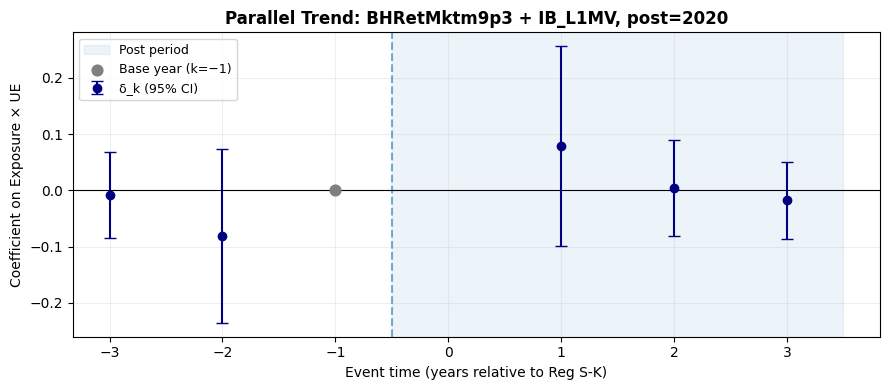

Pre-trend F-test (2 restrictions):
  F = 0.5345,  p = 0.5860  
  ✓ Parallel trend not rejected

Event Study: BHRetMktm9p3 + IB_L1MV, post=2021


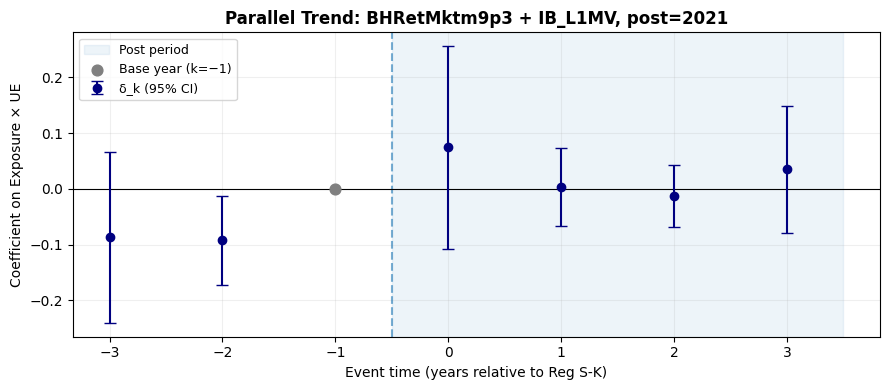

Pre-trend F-test (2 restrictions):
  F = 2.6690,  p = 0.0694  *
  ✗ Parallel trend potentially violated

Event Study: BHRetm9p3 + IB_L1MV, post=2020


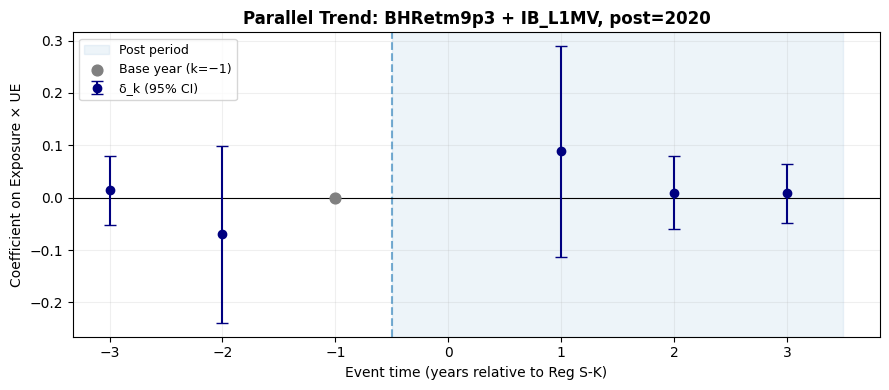

Pre-trend F-test (2 restrictions):
  F = 0.4717,  p = 0.6240  
  ✓ Parallel trend not rejected

Event Study: BHRetm9p3 + IB_L1MV, post=2021


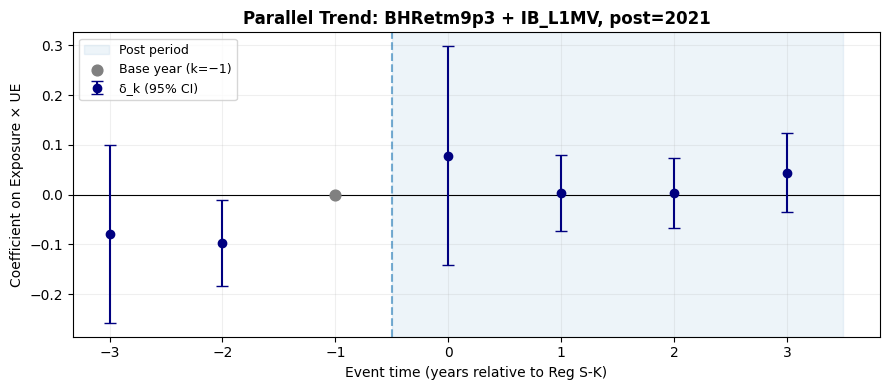

Pre-trend F-test (2 restrictions):
  F = 2.4632,  p = 0.0852  *
  ✗ Parallel trend potentially violated


In [30]:
# ============================================================
# Parallel Trend Test — Event Study
# Spec: BHRetMktm9p3 + IB_L1MV (strongest spec)
# Base year: t = -1
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import f as f_dist

EXPOSURE_VAR = 'exposure_pre_std'
EVENT_LAGS   = 3
EVENT_LEADS  = 3

def run_erc_event_study(df_in, ret_var, ue_var, post_year,
                        exposure_var=EXPOSURE_VAR,
                        lags=EVENT_LAGS, leads=EVENT_LEADS):
    total_window = max(lags, leads) + 1
    lo = post_year - total_window
    hi = post_year + total_window
    d = df_in[(df_in['fyear'] >= lo) & (df_in['fyear'] <= hi)].copy()
    d = d[d['fyear'] != 2020]

    d['event_time'] = (d['fyear'] - post_year).astype(int)
    available = sorted(d['event_time'].unique())
    event_periods = [k for k in range(-lags, leads + 1)
                     if k != -1 and k in available]

    interact_cols = []
    level_cols   = []   # per-event-time exposure level interactions (no UE)
    for k in event_periods:
        col = f'evtk{k}_x_exp_x_ue'   # triple interaction
        d[col] = (d['event_time'] == k).astype(float) * d[exposure_var] * d[ue_var]
        interact_cols.append(col)

        lvl = f'evtk{k}_x_exp'        # event-time × exposure (level), needed
        d[lvl] = (d['event_time'] == k).astype(float) * d[exposure_var]
        level_cols.append(lvl)

    d['exp_x_ue'] = d[exposure_var] * d[ue_var]

    reg_vars = ([ret_var, ue_var, 'exp_x_ue']
                + interact_cols + level_cols
                + [exposure_var, 'gvkey', 'fyear'])
    d = d.dropna(subset=reg_vars)
    d = d.set_index(['gvkey', 'fyear'])

    exog_cols = [ue_var, 'exp_x_ue'] + interact_cols + level_cols
    model = PanelOLS(
        dependent      = d[ret_var],
        exog           = d[exog_cols],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True,
        check_rank     = False
    )
    res = model.fit(cov_type='clustered', cluster_entity=True)
    return res, event_periods, interact_cols


def plot_erc_event_study(res, event_periods, interact_cols, title):
    coefs = [res.params.get(c, np.nan) for c in interact_cols]
    ses   = [res.std_errors.get(c, np.nan) for c in interact_cols]

    plot_ks    = sorted(event_periods + [-1])
    plot_coefs = []
    plot_ses   = []
    for k in plot_ks:
        if k == -1:
            plot_coefs.append(0); plot_ses.append(0)
        else:
            idx = event_periods.index(k)
            plot_coefs.append(coefs[idx]); plot_ses.append(ses[idx])

    plot_coefs = np.array(plot_coefs)
    plot_ses   = np.array(plot_ses)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.axvspan(-0.5, max(plot_ks)+0.5, alpha=0.08, color='C0', label='Post period')
    ax.axvline(-0.5, linestyle='--', color='C0', alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8)

    base_mask  = np.array(plot_ks) == -1
    other_mask = ~base_mask

    ax.errorbar(np.array(plot_ks)[other_mask], plot_coefs[other_mask],
                yerr=1.96*plot_ses[other_mask],
                fmt='o', color='navy', capsize=4, label='δ_k (95% CI)')
    ax.scatter(np.array(plot_ks)[base_mask], plot_coefs[base_mask],
               color='gray', s=60, label='Base year (k=−1)', zorder=3)

    ax.set_xlabel('Event time (years relative to Reg S-K)')
    ax.set_ylabel('Coefficient on Exposure × UE')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''


SPECS = [
    ('BHRetMktm9p3', 'IB_L1MV'),
    ('BHRetm9p3',    'IB_L1MV'),
]

for ret_var, ue_var in SPECS:
    for post_year in [2020, 2021]:
        print(f'\n{"="*65}')
        print(f'Event Study: {ret_var} + {ue_var}, post={post_year}')
        print(f'{"="*65}')
        try:
            res, periods, cols = run_erc_event_study(
                RetEarn_w, ret_var, ue_var, post_year
            )
            plot_erc_event_study(
                res, periods, cols,
                title=f'Parallel Trend: {ret_var} + {ue_var}, post={post_year}'
            )
            # Pre-trend F-test (manual Wald)
            pre_cols = [c for c in cols if 'evtk-' in c or
                        any(f'evtk{k}_' in c for k in range(-EVENT_LAGS, 0))]
            if pre_cols:
                param_names = list(res.params.index)
                R = np.zeros((len(pre_cols), len(param_names)))
                for i, col in enumerate(pre_cols):
                    if col in param_names:
                        R[i, param_names.index(col)] = 1
                b   = res.params.values
                V   = res.cov.values
                Rb  = R @ b
                RVR = R @ V @ R.T
                F   = float((Rb @ np.linalg.inv(RVR) @ Rb) / len(pre_cols))
                p   = 1 - f_dist.cdf(F, len(pre_cols), res.df_resid)
                print(f'Pre-trend F-test ({len(pre_cols)} restrictions):')
                print(f'  F = {F:.4f},  p = {p:.4f}  {stars(p)}')
                if p < 0.10:
                    print('  ✗ Parallel trend potentially violated')
                else:
                    print('  ✓ Parallel trend not rejected')
            else:
                print('No pre-period dummies found for F-test.')
        except Exception as e:
            print(f'ERROR: {e}')

---
## Export Results

In [31]:
# ── 10. Export results to Excel ──────────────────────────────────────────────
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font, PatternFill, Alignment
import os

def df_to_sheet(ws, df, title):
    ws.title = title[:31]
    for r in dataframe_to_rows(df, index=True, header=True):
        ws.append(r)
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.fill = PatternFill('solid', fgColor='DCE6F1')
        cell.alignment = Alignment(horizontal='center')

wb = Workbook()

# Sheet 1: Main results
ws1 = wb.active
df_to_sheet(ws1, summary_erc, 'Main_ERC')

# Sheet 2: Robustness excl 2020
rows_r = []
for (rv, uv, py, w), (res, _) in results_erc_excl2020.items():
    b1 = res.params[uv];            p1 = res.pvalues[uv]
    b2 = res.params['Post_x_UE'];   p2 = res.pvalues['Post_x_UE']
    b3 = res.params['HCD_x_UE'];    p3 = res.pvalues['HCD_x_UE']
    b4 = res.params['Post_x_HCD_x_UE']; p4 = res.pvalues['Post_x_HCD_x_UE']
    rows_r.append({
        'Return': rv, 'UE': uv, 'Post Year': py, 'Window': f'±{w}',
        'N': int(res.nobs),
        'β1 (UE)':          f'{b1:.4f}{stars(p1)}',
        'β2 (Post×UE)':     f'{b2:.4f}{stars(p2)}',
        'β3 (HCD×UE)':      f'{b3:.4f}{stars(p3)}',
        'β5 (Post×HCD×UE)': f'{b4:.4f}{stars(p4)}',
        'R²': f'{res.rsquared:.4f}',
    })
ws2 = wb.create_sheet()
df_to_sheet(ws2, pd.DataFrame(rows_r), 'Robustness_Excl2020')

# Sheet 3: Descriptive stats
ws3 = wb.create_sheet()
df_to_sheet(ws3, desc.round(4), 'Descriptive_Stats')

out_path = os.path.join(OUT_DIR, 'erc_results.xlsx')
wb.save(out_path)
print(f'Exported to {out_path}')


Exported to /Users/zhouyeyang/Univ. of Oklahoma Dropbox/Yeyang Zhou/Y1S2/Agnes Seminar/Final project/output/erc_results.xlsx


## Print Cell Outputs

In [32]:
import json

with open('erc_hcd_v9.ipynb', 'r') as f:
    nb = json.load(f)

outputs = []
for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code' and cell.get('outputs'):
        text = ''
        for out in cell['outputs']:
            if 'text' in out:
                text += ''.join(out['text'])
            elif 'traceback' in out:
                text += ''.join(out['traceback'][-3:])  # last 3 lines of traceback
        if text.strip():
            outputs.append(f'--- Cell {i} ---\n{text.strip()}')

print('\n\n'.join(outputs))

## Beta4

In [33]:
# ── Extract β₄ (Post × HCD) for focal spec ──────────────────────────────────
# Uses results_erc and results_erc_excl2020 already in kernel memory.

FOCAL_RET = 'BHRetMktm9p3'
FOCAL_UE  = 'IB_L1MV'
POST_YR   = 2020

def get_b4(d, label):
    print(f"\n=== {label} ===")
    for w in [3, 5]:
        key = (FOCAL_RET, FOCAL_UE, POST_YR, w)
        if key not in d:
            print(f"  ±{w}: KEY NOT FOUND")
            continue
        res = d[key][0] if isinstance(d[key], tuple) else d[key]
        b = res.params['Post_x_HCD']
        p = res.pvalues['Post_x_HCD']
        t = res.tstats['Post_x_HCD']
        print(f"  ±{w}: β₄ = {b:+.4f}{stars(p)}  (t = {t:+.2f}, p = {p:.4f})")

get_b4(results_erc,          'Main: β₄ (Post × HCD)')
get_b4(results_erc_excl2020, 'Excl FY2020: β₄ (Post × HCD)')


=== Main: β₄ (Post × HCD) ===
  ±3: β₄ = -0.0415***  (t = -4.82, p = 0.0000)
  ±5: β₄ = -0.0320***  (t = -4.88, p = 0.0000)

=== Excl FY2020: β₄ (Post × HCD) ===
  ±3: β₄ = -0.0291***  (t = -3.33, p = 0.0009)
  ±5: β₄ = -0.0226***  (t = -3.46, p = 0.0005)


---
## v9 — Strict Intersection Sample for Paper Tables

For the term paper, all in-paper tables must report a single uniform sample size. The cells below define a **strict intersection sample** where all four UE measures, the main DV (BHRetMktm9p3), and HCD are non-missing simultaneously. UE_IBES is dropped from the paper.

- **Tables 1, 2, 3** (sample selection, descriptives, main ERC): use the strict sample defined by main spec (Post=2020, ±3).
- **Table 4** (robustness): each (post_year, window, excl_2020) cell uses its own strict intersection. N varies across columns but is uniform within each column (across UE measures).

The v8 cells above run on the broader HCD-matched sample and remain unchanged for diagnostic comparison.

In [34]:
# v9 Cell A: Strict sample definition + Table 1 extended waterfall

UE_VARS_PAPER = ['c1IB_L1MV', 'IB_L1MV', 'c1IB_L1P', 'c1IB_L1TA']
MAIN_RET   = 'BHRetMktm9p3'
MAIN_POST  = 2020
MAIN_WIN   = 3

def build_strict_sample(df, post_year, window, excl_2020=False):
    """Return df restricted to post_year+/-window with all 4 UE, main DV, and HCD non-missing."""
    lo, hi = post_year - window, post_year + window
    d = df[(df['fyear'] >= lo) & (df['fyear'] <= hi)].copy()
    if excl_2020:
        d = d[d['fyear'] != 2020].copy()
    required = UE_VARS_PAPER + [MAIN_RET, 'exposure_pre_std']
    return d.dropna(subset=required)

print('=== Table 1 EXTENDED: Sample Selection (down to regression sample) ===\n')
print(f"{'Step':<70}{'N obs':>10}{'N firms':>10}")
print('-' * 90)

hcd_matched = RetEarn_w[RetEarn_w['exposure_pre_std'].notna()].copy()
print(f"{'8. HCD-matched FY2015-2024 (winsorized)':<70}"
      f"{len(hcd_matched):>10,}{hcd_matched['gvkey'].nunique():>10,}")

step9 = hcd_matched[hcd_matched[MAIN_RET].notna()].copy()
print(f"{'9. After requiring non-missing BHRetMktm9p3':<70}"
      f"{len(step9):>10,}{step9['gvkey'].nunique():>10,}")

step10 = step9.dropna(subset=UE_VARS_PAPER).copy()
print(f"{'10. After requiring all 4 UE measures non-missing':<70}"
      f"{len(step10):>10,}{step10['gvkey'].nunique():>10,}")

strict_main = step10[step10['fyear'].between(MAIN_POST - MAIN_WIN, MAIN_POST + MAIN_WIN)].copy()
print(f"{'11. After +/-3 window around FY2020 (FY2017-2023) = STRICT MAIN SAMPLE':<70}"
      f"{len(strict_main):>10,}{strict_main['gvkey'].nunique():>10,}")

print(f"\n*** STRICT MAIN-SPEC SAMPLE: {len(strict_main):,} firm-years / "
      f"{strict_main['gvkey'].nunique():,} firms ***")


=== Table 1 EXTENDED: Sample Selection (down to regression sample) ===

Step                                                                       N obs   N firms
------------------------------------------------------------------------------------------
8. HCD-matched FY2015-2024 (winsorized)                                  116,942     5,664
9. After requiring non-missing BHRetMktm9p3                               85,569     4,421
10. After requiring all 4 UE measures non-missing                         79,343     4,231
11. After +/-3 window around FY2020 (FY2017-2023) = STRICT MAIN SAMPLE    17,544     3,248

*** STRICT MAIN-SPEC SAMPLE: 17,544 firm-years / 3,248 firms ***


In [35]:
# v9 Cell B: Table 2 descriptive statistics on strict main sample

print('=== Table 2: Descriptive Statistics on Strict Regression Sample ===')
print(f'Sample: {len(strict_main):,} firm-years / {strict_main["gvkey"].nunique():,} firms')
print(f'(Main spec: +/-3 around FY2020, all 4 UE + main DV + HCD non-missing)\n')

DESC_VARS_PAPER = [MAIN_RET] + UE_VARS_PAPER + ['exposure_pre_std', 'exposure_pre']
desc_paper = strict_main[[v for v in DESC_VARS_PAPER if v in strict_main.columns]].describe(
    percentiles=[0.25, 0.5, 0.75]
).T
desc_paper = desc_paper[['count','mean','std','min','25%','50%','75%','max']]
desc_paper.columns = ['N','Mean','Std','Min','P25','Median','P75','Max']
desc_paper['N'] = desc_paper['N'].astype(int)
print(desc_paper.to_string(float_format='{:.4f}'.format))


=== Table 2: Descriptive Statistics on Strict Regression Sample ===
Sample: 17,544 firm-years / 3,248 firms
(Main spec: +/-3 around FY2020, all 4 UE + main DV + HCD non-missing)

                      N    Mean    Std     Min     P25  Median    P75    Max
BHRetMktm9p3      17544 -0.0276 0.5742 -0.8716 -0.3695 -0.1043 0.1742 2.3425
c1IB_L1MV         17544  0.0214 0.3873 -1.7041 -0.0381  0.0016 0.0369 3.0903
IB_L1MV           17544 -0.1211 0.4450 -3.2861 -0.1307  0.0107 0.0528 0.6264
c1IB_L1P          17544 -0.0233 0.6037 -3.0899 -0.0307  0.0036 0.0433 3.4335
c1IB_L1TA         17544 -0.0048 0.3085 -2.6680 -0.0501  0.0025 0.0451 2.2076
exposure_pre_std  17544  0.0851 1.0037 -1.6301 -0.5393 -0.0755 0.4225 8.3044
exposure_pre      17544  0.0113 0.0066  0.0000  0.0072  0.0102 0.0135 0.0655


In [36]:
# v9 Cell C: Table 3 main ERC regression on strict sample
# All 4 UE measures should yield exactly the same N within the strict sample.

print('=== Table 3: Main ERC Regression on Strict Sample ===')
print(f'Spec: ret={MAIN_RET}, post={MAIN_POST}, window=+/-{MAIN_WIN}\n')

rows_t3 = []
for ue_var in UE_VARS_PAPER:
    res, samp = run_erc_regression(strict_main, MAIN_RET, ue_var, MAIN_POST, MAIN_WIN)
    b1 = res.params[ue_var];              p1 = res.pvalues[ue_var]
    b2 = res.params['Post_x_UE'];         p2 = res.pvalues['Post_x_UE']
    b3 = res.params['HCD_x_UE'];          p3 = res.pvalues['HCD_x_UE']
    b4 = res.params['Post_x_HCD'];        p4 = res.pvalues['Post_x_HCD']
    b5 = res.params['Post_x_HCD_x_UE'];   p5 = res.pvalues['Post_x_HCD_x_UE']
    rows_t3.append({
        'UE':                 ue_var,
        'N':                  int(res.nobs),
        'R2(within)':         f'{res.rsquared_within:.4f}',
        'b1 (UE)':            f'{b1:+.4f}{stars(p1)}',
        'b2 (PostxUE)':       f'{b2:+.4f}{stars(p2)}',
        'b3 (HCDxUE)':        f'{b3:+.4f}{stars(p3)}',
        'b4 (PostxHCD)':      f'{b4:+.4f}{stars(p4)}',
        'b5 (PostxHCDxUE)':   f'{b5:+.4f}{stars(p5)}',
    })

import pandas as pd
t3_df = pd.DataFrame(rows_t3).set_index('UE')
print(t3_df.to_string())


=== Table 3: Main ERC Regression on Strict Sample ===
Spec: ret=BHRetMktm9p3, post=2020, window=+/-3

               N R2(within)     b1 (UE) b2 (PostxUE) b3 (HCDxUE) b4 (PostxHCD) b5 (PostxHCDxUE)
UE                                                                                             
c1IB_L1MV  17544     0.0122  +0.1294***     +0.0679*     +0.0031    -0.0444***          -0.0266
IB_L1MV    17544     0.0115     -0.0197   -0.1043***     -0.0481    -0.0415***        +0.0903**
c1IB_L1P   17544     0.0131  +0.0840***      +0.0317     -0.0038    -0.0444***          -0.0103
c1IB_L1TA  17544     0.0034     +0.0717      +0.0689    -0.0652*    -0.0450***         +0.0708*


In [37]:
# v9 Cell D: Table 4 robustness, per-cell strict intersection
# Each (post_year, window, excl_2020) cell uses its own strict sample.
# Within each column N is uniform across UE rows; across columns N varies.

print('=== Table 4: Robustness b5 -- per-cell strict intersection ===\n')

for panel_name, excl in [('Panel A: Including FY2020', False),
                          ('Panel B: Excluding FY2020', True)]:
    print(panel_name)
    spec_cols = []
    for post_year in POST_YEAR_OPTIONS:
        for window in WINDOW_OPTIONS:
            spec_cols.append((post_year, window))

    n_per_col = {}
    for (py, w) in spec_cols:
        d = build_strict_sample(RetEarn_w, py, w, excl_2020=excl)
        n_per_col[(py, w)] = len(d)

    header = f"  {'UE measure':<14}" + ''.join(
        f'{f"Post={py},+/-{w}":>18}' for (py, w) in spec_cols
    )
    n_row = f"  {'N (firm-yrs)':<14}" + ''.join(
        f'{n_per_col[(py,w)]:>18,}' for (py, w) in spec_cols
    )
    print(header)
    print(n_row)
    print('  ' + '-' * (14 + 18 * len(spec_cols)))

    for ue_var in UE_VARS_PAPER:
        cells = []
        for (py, w) in spec_cols:
            d = build_strict_sample(RetEarn_w, py, w, excl_2020=excl)
            res, _ = run_erc_regression(d, MAIN_RET, ue_var, py, w, excl_2020=excl)
            b5 = res.params['Post_x_HCD_x_UE']
            p5 = res.pvalues['Post_x_HCD_x_UE']
            cells.append(f'{b5:+.4f}{stars(p5)}')
        print(f"  {ue_var:<14}" + ''.join(f'{c:>18}' for c in cells))
    print()


=== Table 4: Robustness b5 -- per-cell strict intersection ===

Panel A: Including FY2020
  UE measure        Post=2020,+/-3    Post=2020,+/-5    Post=2021,+/-3    Post=2021,+/-5
  N (firm-yrs)              17,544            25,379            17,242            22,788
  --------------------------------------------------------------------------------------
  c1IB_L1MV                -0.0266           -0.0243           -0.0545         -0.0668**
  IB_L1MV                +0.0903**        +0.1023***           -0.0003           +0.0094
  c1IB_L1P                 -0.0103           -0.0095           -0.0290          -0.0391*
  c1IB_L1TA               +0.0708*           +0.0447           -0.0559           -0.0614

Panel B: Excluding FY2020
  UE measure        Post=2020,+/-3    Post=2020,+/-5    Post=2021,+/-3    Post=2021,+/-5
  N (firm-yrs)              14,993            22,828            14,691            20,237
  --------------------------------------------------------------------------------

## Pirnt

---
## Figure: Distribution of pre-mandate HCD intensity


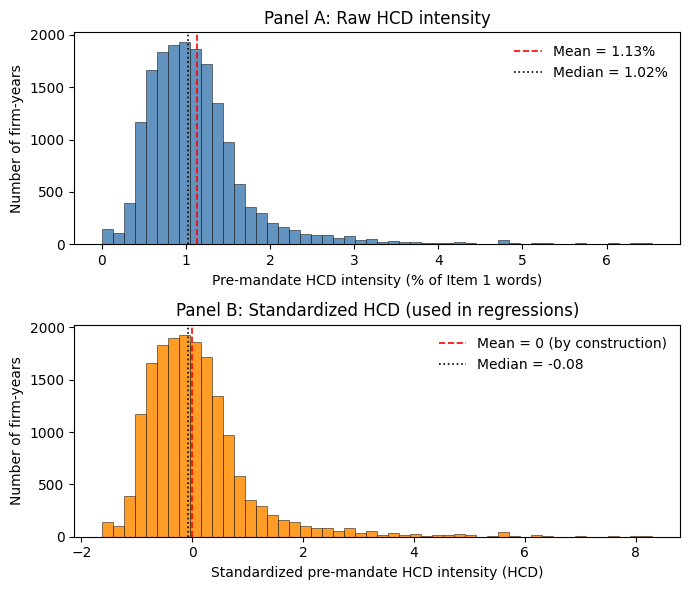

Figure saved to: /Users/zhouyeyang/Univ. of Oklahoma Dropbox/Yeyang Zhou/Y1S2/Agnes Seminar/Final project/output/fig_hcd_distribution.png


In [38]:
# ── v9 Figure: HCD distribution (raw + standardized) ───────────────
import matplotlib.pyplot as plt

FIG_PATH = f'{OUT_DIR}/fig_hcd_distribution.png'

fig, axes = plt.subplots(2, 1, figsize=(7, 6))

# Top: raw HCD intensity (in percent for readability)
raw = strict_main['exposure_pre'].dropna() * 100
axes[0].hist(raw, bins=50, edgecolor='black', linewidth=0.4, color='steelblue', alpha=0.85)
axes[0].axvline(raw.mean(), color='red', linestyle='--', linewidth=1.2,
                label=f'Mean = {raw.mean():.2f}%')
axes[0].axvline(raw.median(), color='black', linestyle=':', linewidth=1.2,
                label=f'Median = {raw.median():.2f}%')
axes[0].set_xlabel('Pre-mandate HCD intensity (% of Item 1 words)')
axes[0].set_ylabel('Number of firm-years')
axes[0].set_title('Panel A: Raw HCD intensity')
axes[0].legend(frameon=False)

# Bottom: standardized
std = strict_main['exposure_pre_std'].dropna()
axes[1].hist(std, bins=50, edgecolor='black', linewidth=0.4, color='darkorange', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Mean = 0 (by construction)')
axes[1].axvline(std.median(), color='black', linestyle=':', linewidth=1.2,
                label=f'Median = {std.median():.2f}')
axes[1].set_xlabel('Standardized pre-mandate HCD intensity (HCD)')
axes[1].set_ylabel('Number of firm-years')
axes[1].set_title('Panel B: Standardized HCD (used in regressions)')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_PATH, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figure saved to: {FIG_PATH}')
